In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/novagen_dataset.csv")

In [25]:
df.head()
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9549 entries, 0 to 9548
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    9549 non-null   float64
 1   BMI                    9549 non-null   float64
 2   Blood_Pressure         9549 non-null   float64
 3   Cholesterol            9549 non-null   float64
 4   Glucose_Level          9549 non-null   float64
 5   Heart_Rate             9549 non-null   float64
 6   Sleep_Hours            9549 non-null   float64
 7   Exercise_Hours         9549 non-null   float64
 8   Water_Intake           9549 non-null   float64
 9   Stress_Level           9549 non-null   float64
 10  Target                 9549 non-null   int64  
 11  Smoking                9549 non-null   int64  
 12  Alcohol                9549 non-null   int64  
 13  Diet                   9549 non-null   int64  
 14  MentalHealth           9549 non-null   int64  
 15  Phys

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level,...,Diet,MentalHealth,PhysicalActivity,MedicalHistory,Allergies,Diet_Type__Vegan,Diet_Type__Vegetarian,Blood_Group_AB,Blood_Group_B,Blood_Group_O
count,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,...,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000,9549.000000
mean,33.806786,25.660697,130.382658,199.091528,100.225678,73.613782,6.951409,1.892345,3.580899,4.382134,...,1.005864,0.998429,1.003351,1.004713,0.989318,0.329354,0.335742,0.244947,0.253849,0.252592
std,24.566473,1.942369,27.878476,1.969234,2.157999,1.681538,2.352152,1.378714,1.622874,2.078593,...,0.815877,0.821844,0.808800,0.813506,0.815699,0.470003,0.472274,0.430078,0.435235,0.434522
min,0.000000,19.000000,22.000000,192.000000,93.000000,67.000000,0.000000,-0.000000,-0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,14.000000,24.000000,113.000000,198.000000,99.000000,73.000000,5.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,29.000000,26.000000,134.000000,199.000000,100.000000,74.000000,7.000000,2.000000,4.000000,4.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,50.000000,27.000000,150.000000,200.000000,102.000000,75.000000,9.000000,3.000000,5.000000,6.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,100.000000,32.000000,225.000000,207.000000,107.000000,80.000000,14.000000,8.000000,10.000000,12.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
# How blance our class are?
classes_count = df["Target"].value_counts()
print(classes_count)

Target
1    4979
0    4570
Name: count, dtype: int64


# Data Visualization

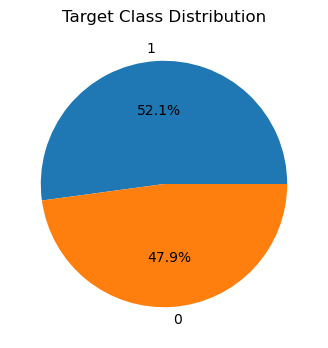

In [24]:
plt.figure(figsize=(6,4))

plt.pie(classes_count, labels=["1", "0"], autopct="%1.1f%%")
plt.title("Target Class Distribution")
plt.show()

In [35]:
# Check age as newborn
df[df["Age"] == 0].shape[0]

96

In [34]:
# Blood Pressure Validation
df[(df["Blood_Pressure"] < 50) | (df["Blood_Pressure"] > 200)].shape[0]

41

In [39]:
# Stress Level Validation
print(df[df["Stress_Level"] > 10].shape[0])
df["Stress_Level"].value_counts().sort_index()

24


Stress_Level
-0.0      185
 1.0      582
 2.0     1047
 3.0     1528
 4.0     1761
 5.0     1679
 6.0     1297
 7.0      795
 8.0      398
 9.0      186
 10.0      67
 11.0      17
 12.0       7
Name: count, dtype: int64

In [36]:
# smoking validation
df["Smoking"].value_counts().sort_index()

Smoking
0    3221
1    3198
2    3130
Name: count, dtype: int64

In [40]:
# Alcohol Validation
df["Alcohol"].value_counts().sort_index()

Alcohol
0    3207
1    3181
2    3161
Name: count, dtype: int64

In [41]:
categorical_cols = [
    "Smoking",
    "Alcohol",
    "Diet",
    "MentalHealth",
    "PhysicalActivity",
    "MedicalHistory",
    "Allergies"
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts().sort_index())


Smoking
Smoking
0    3221
1    3198
2    3130
Name: count, dtype: int64

Alcohol
Alcohol
0    3207
1    3181
2    3161
Name: count, dtype: int64

Diet
Diet
0    3150
1    3193
2    3206
Name: count, dtype: int64

MentalHealth
MentalHealth
0    3232
1    3100
2    3217
Name: count, dtype: int64

PhysicalActivity
PhysicalActivity
0    3107
1    3303
2    3139
Name: count, dtype: int64

MedicalHistory
MedicalHistory
0    3137
1    3230
2    3182
Name: count, dtype: int64

Allergies
Allergies
0    3228
1    3195
2    3126
Name: count, dtype: int64


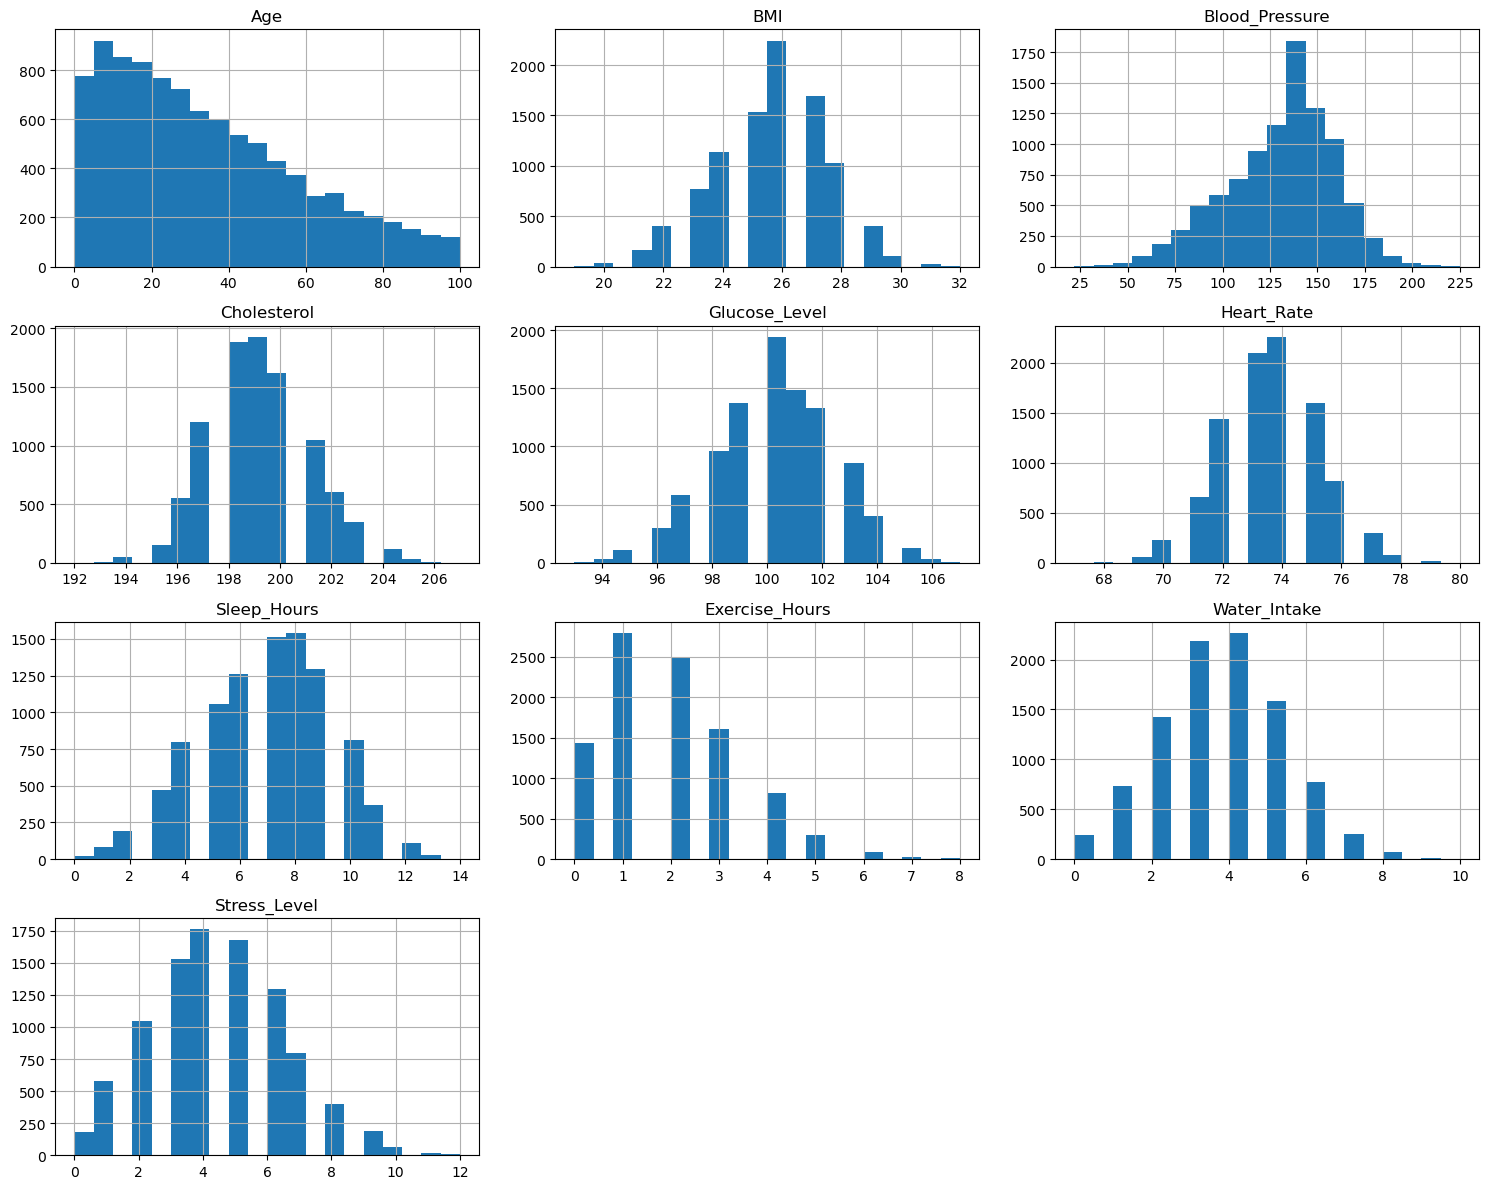

In [42]:
# Analyze numerical features visually

numeric_cols = [
    "Age",
    "BMI",
    "Blood_Pressure",
    "Cholesterol",
    "Glucose_Level",
    "Heart_Rate",
    "Sleep_Hours",
    "Exercise_Hours",
    "Water_Intake",
    "Stress_Level"
]

df[numeric_cols].hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()

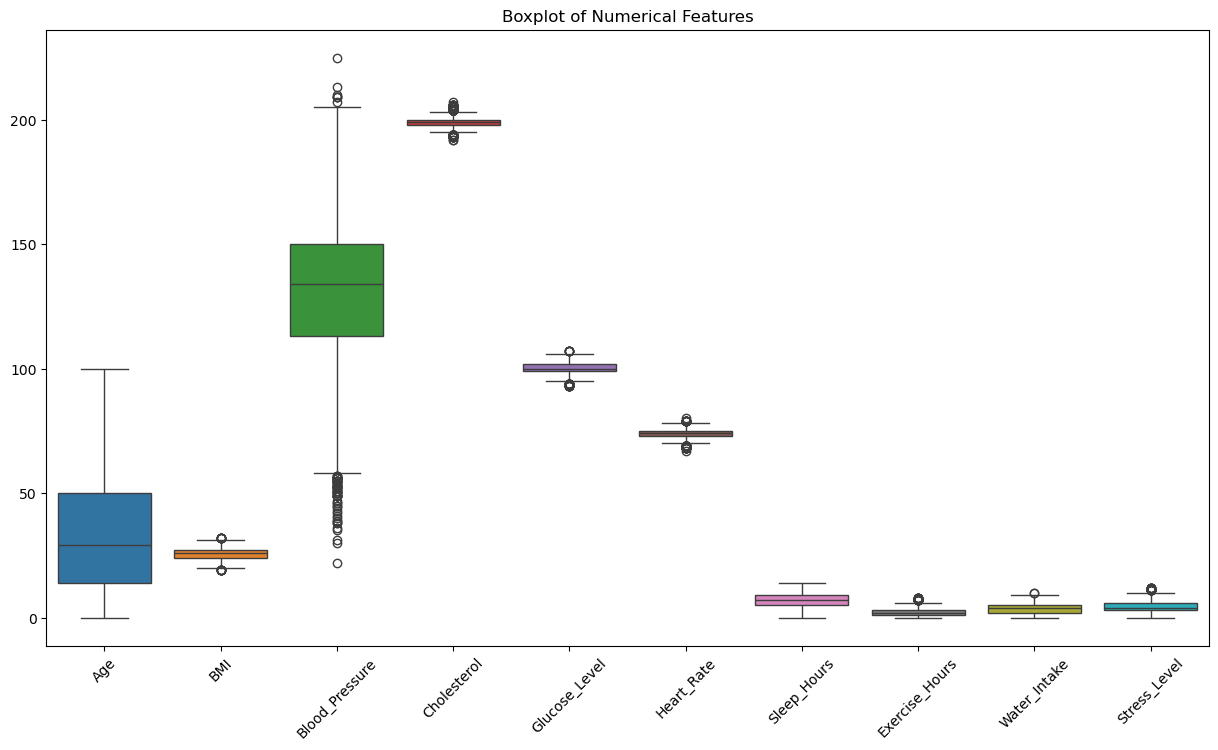

In [45]:
# Boxplots for outliers

plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_cols])

plt.xticks(rotation=45)
plt.title("Boxplot of Numerical Features")
plt.show()

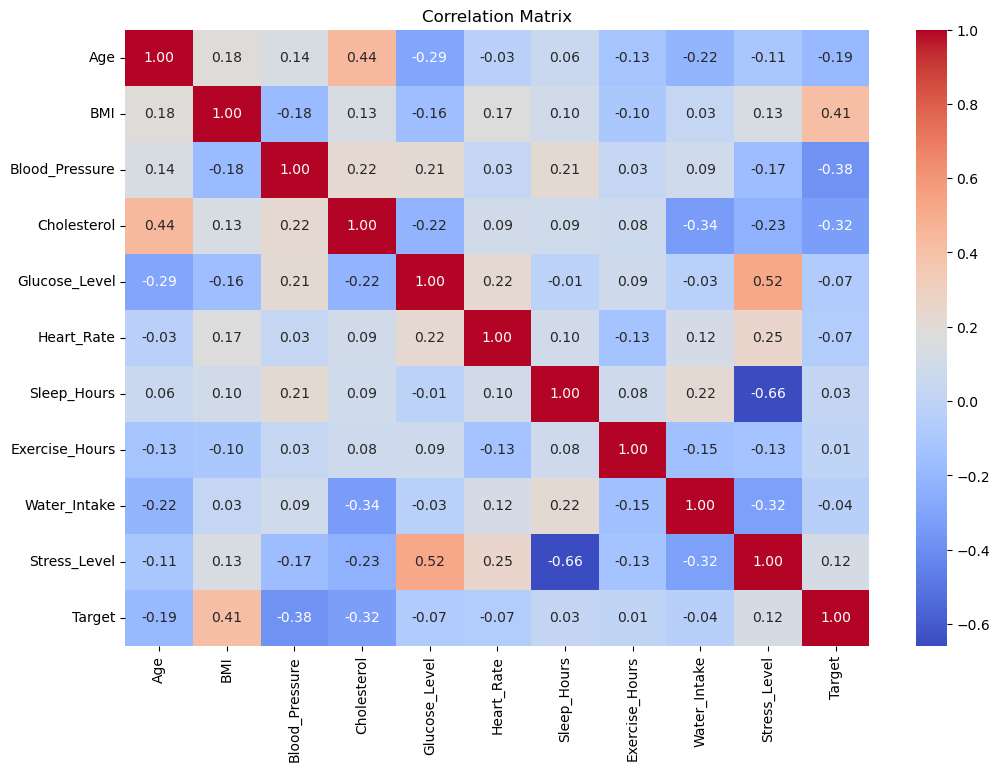

In [48]:
# Correlation analysis

plt.figure(figsize=(12, 8))

corr = df[numeric_cols + ["Target"]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap = "coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

In [51]:
corr["Target"].sort_values(ascending = False)

Target            1.000000
BMI               0.413972
Stress_Level      0.119455
Sleep_Hours       0.025931
Exercise_Hours    0.008214
Water_Intake     -0.038406
Heart_Rate       -0.065957
Glucose_Level    -0.072148
Age              -0.190743
Cholesterol      -0.324361
Blood_Pressure   -0.380279
Name: Target, dtype: float64

In [52]:
# mean based on class
df.groupby("Target")[
    ["Age", "BMI", "Blood_Pressure", "Cholesterol",
     "Glucose_Level", "Heart_Rate", "Sleep_Hours",
     "Exercise_Hours", "Water_Intake", "Stress_Level"]
].mean()

,Age,BMI,Blood_Pressure,Cholesterol,Glucose_Level,Heart_Rate,Sleep_Hours,Exercise_Hours,Water_Intake,Stress_Level
Target,,,,,,,,,,
0,38.697593,24.821444,141.447921,199.758206,100.388184,73.729540,6.887746,1.880525,3.645952,4.122976
1,29.317734,26.431010,120.226351,198.479614,100.076521,73.507532,7.009841,1.903193,3.521189,4.620004


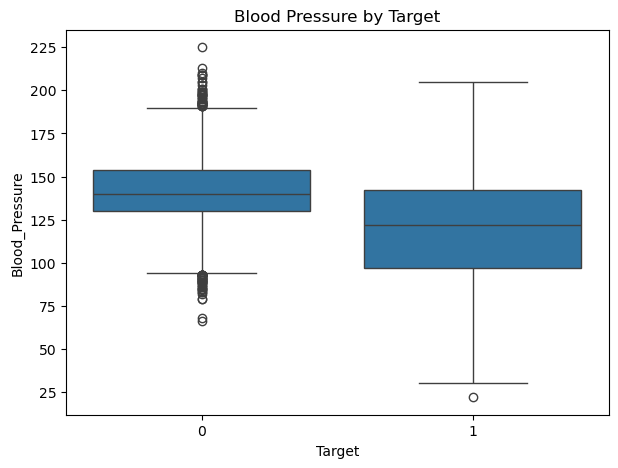

In [53]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Target",
    y="Blood_Pressure"
)

plt.title("Blood Pressure by Target")
plt.show()

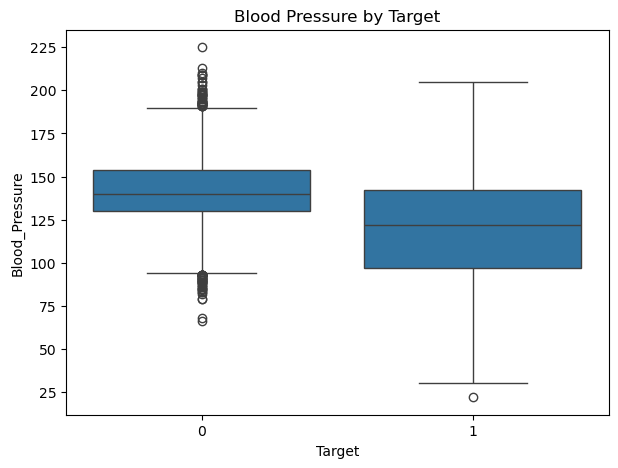

In [54]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="Target",
    y="Blood_Pressure"
)

plt.title("Blood Pressure by Target")
plt.show()